In [14]:
# 1. Librerías estándar del sistema
import os
import sys
import collections
from datetime import datetime

# 2. Librerías de terceros (Instaladas vía pip/conda)
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import rasterio
from rasterio.windows import from_bounds
import qrcode
import gspread
import tkinter as tk
from tkinter import filedialog as fd
import numpy as np

# Específicas de documentos y GIS
import docxtpl
from docxtpl import DocxTemplate, InlineImage  # Combinado en una sola línea
from docx.shared import Mm
from rasterio.plot import show
from matplotlib.patches import Patch
from sqlalchemy import create_engine, text

# 3. Importaciones locales (Tus archivos)
sys.path.append('..')
from config import RUTA_UNIDAD_ONE_DRIVE, RUTA_LOCAL_ONE_DRIVE, POSTGRES_UTEA

# Configuración de base de datos
USER_DB = POSTGRES_UTEA['USER']
PASS_DB = POSTGRES_UTEA['PASSWORD']
HOST_DB = POSTGRES_UTEA['HOST']
PORT_DB = POSTGRES_UTEA['PORT']
NAME_DB = POSTGRES_UTEA['DATABASE']

In [21]:
# funcion que retorna el encale para conectar a base de datos
def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{POSTGRES_UTEA['USER']}:{POSTGRES_UTEA['PASSWORD']}@{POSTGRES_UTEA['HOST']}:{POSTGRES_UTEA['PORT']}/{POSTGRES_UTEA['DATABASE']}"
    )

# obtener todo el catastro de la base datos
def get_catastro():
    engine = get_engine()
    try:
        query = """
            SELECT * FROM catastro_iag.catastro
        """
        gdf = gpd.read_postgis(query, engine, geom_col='geom')
        return gdf
    except Exception as e:
        print(f"❌ Error en get_catastro(): {e}")
        return gpd.GeoDataFrame()
    return None

def inserct_registro_y_get_id(fecha, codigo, nombre, tipo):
    engine = get_engine()
    # Definimos la consulta con la cláusula RETURNING
    query = text("""
        INSERT INTO catastro_iag.cite (fecha, codigo, nombre, tipo)
        VALUES (:fecha, :codigo, :nombre, :tipo)
        RETURNING nro; 
    """)
    try:
        with engine.connect() as conn:
            # Ejecutamos y obtenemos el primer resultado (el ID generado)
            result = conn.execute(query, {
                "fecha": fecha,
                "codigo": codigo,
                "nombre": nombre,
                "tipo": tipo
            })
            # Confirmamos los cambios (necesario en versiones recientes de SQLAlchemy)
            conn.commit()
            # .scalar() extrae el valor único de la primera columna de la primera fila
            nuevo_id = result.scalar()
            return nuevo_id
    except Exception as e:
        print(f"❌ Error al registra nuevo CITE: {e}")
        return None

def get_qr(grupo, cod_delegado, nom_delegado):
    texto = '''
--UTEA--
--DATOS CATASTRALES--
Codigo informe: {cod_inf}
Fecha de emición: {fecha}
Nombre de Canero: {canero}
Codigo Canero: {cod_ca}
Tipo de informe: {tipo}'''\
    .format(
    cod_inf=str(grupo.cite) + '-' + grupo.fecha[6:], 
    fecha=grupo.fecha, 
    canero=cod_delegado,
    cod_ca=nom_delegado,
    tipo='Informe de programa de control biologico')
    # Generar el código QR
    qr = qrcode.QRCode(
        version=1,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=10,
        border=4,
    )
    qr.add_data(texto)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")
    filename_qr = 'qr_' + str(cod_delegado) + '_' + grupo.fecha.replace('/', '-')
    path_qr = PATH_COMPLETO + '/planos/' + filename_qr + '.png'
    #Guardar el código QR en un archivo
    img.save(path_qr)
    return path_qr


In [3]:
def generar_plano(shp_prop, shp_prop_selct, path_tif, area_aplicar):
    # 1. CONFIGURACIÓN DE DIMENSIONES FIJAS (1000x600 px) ### NUEVO ###
    ancho_px, alto_px = 1000, 600
    mi_dpi = 100 
    relacion_aspecto = ancho_px / alto_px

    # 1. DEFINIR EL ÁREA DE INTERÉS (Bounding Box)
    bounds = shp_prop.total_bounds  # [xmin, ymin, xmax, ymax]
    
    # Añadimos un margen para que el plano no quede tan ajustado (ej. 500 metros)
    margen = 500
    west, south, east, north = (bounds[0]-margen, bounds[1]-margen, 
                                 bounds[2]+margen, bounds[3]+margen)
    
    # 2. LEER SOLO LO NECESARIO CON RASTERIO
    with rasterio.open(path_tif) as src:
        # Convertimos coordenadas geográficas a una "ventana" de píxeles
        window = from_bounds(west, south, east, north, transform=src.transform)
        
        # Leemos solo esa ventana y aplicamos un re-muestreo (opcional) para ahorrar más RAM
        img = src.read([1, 2, 3], window=window, boundless=True, fill_value=0)
        
        # Actualizamos el transform de la ventana para que coincida con el recorte
        win_transform = src.window_transform(window)

        if img.dtype in ['float32', 'float64']:
            img = np.clip(img, 0, 1)

    # 3. CREAR FIGURA
    fig, ax = plt.subplots(figsize=(ancho_px / mi_dpi, alto_px / mi_dpi))

    # IMPORTANTE: Usamos el transform de la ventana recortada
    show(img, transform=win_transform, ax=ax)
    
    # Graficar propiedades
    shp_prop.plot(ax=ax, edgecolor='red', facecolor=(0, 0, 0, 0), linewidth=1)
    shp_prop_selct.plot(ax=ax, edgecolor='yellow', facecolor=(0, 0, 0, 0), linewidth=1.2)

    # Etiquetas de lotes
    for idx, row in shp_prop.iterrows():
        if row.geom is not None:
            label = f"{row['unidad_05']}\n{round(row['area'], 2)} ha"
            centroid = row.geom.representative_point()
            ax.text(centroid.x, centroid.y, label, fontsize=7, ha='center', color='black', 
                    weight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.4, pad=0))

    # Título
    nom_prop = shp_prop["unidad_02"].iloc[0]
    cod_prop = shp_prop["unidad_01"].iloc[0]
    ax.set_title(f"{int(cod_prop)} / {nom_prop}", fontsize=12, pad=10)

    # 3. CÁLCULO DE ZOOM PARA FORZAR RELACIÓN DE ASPECTO 1000:600 ### NUEVO ###
    bounds = shp_prop.total_bounds  # [xmin, ymin, xmax, ymax]
    centro_x = (bounds[0] + bounds[2]) / 2
    centro_y = (bounds[1] + bounds[3]) / 2
    
    ancho_lote = (bounds[2] - bounds[0]) + 800 # margen de 400 a cada lado
    alto_lote = (bounds[3] - bounds[1]) + 800
    
    # Determinamos el rango visual basado en la relación 1.66 (1000/600)
    rango_visual = max(ancho_lote, alto_lote * relacion_aspecto)
    
    ax.set_xlim(centro_x - rango_visual / 2, centro_x + rango_visual / 2)
    ax.set_ylim(centro_y - (rango_visual / relacion_aspecto) / 2, 
                centro_y + (rango_visual / relacion_aspecto) / 2)

    # 4. ESTÉTICA FINAL
    ax.set_aspect('equal')
    ax.axis('off') # Si quieres que sea exactamente 1000x600 sin bordes blancos de ejes

    # Leyenda
    legend_elements = [
        Patch(facecolor=(0, 0, 0, 0), edgecolor='red', label='Lotes Propiedad'),
        Patch(facecolor=(0, 0, 0, 0), edgecolor='yellow', label='Lotes aplicar (' + str(round(area_aplicar,2)) + ' ha)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9, frameon=True)

    ax.set_aspect('equal') 
    ax.axis('off')
    
    # 4. LIMPIEZA TOTAL DE MEMORIA AL FINAL
    plt.subplots_adjust(left=0, right=1, top=0.92, bottom=0)
    path_output = RUTA_UNIDAD_ONE_DRIVE + r"\OneDrive - Ingenio Azucarero Guabira S.A\_DATOS_PYTHON\planos/plano_INBA_" + str(int(cod_prop)) + "_" + nom_prop + '.jpg'
    fig.savefig(path_output, dpi=mi_dpi)
    
    plt.close(fig)      # Cierra la figura actual
    plt.clf()            # Limpia la figura
    plt.cla()            # Limpia los ejes
    del img              # Borra la variable de la imagen de la RAM
    
    return path_output

In [4]:
# ruta de _DATOS_PYTHON
PATH_COMPLETO = os.path.join(RUTA_UNIDAD_ONE_DRIVE, RUTA_LOCAL_ONE_DRIVE)
# ruta de grupos de trabajo de la camapaña actual
PATH_GRUPOS_TRABAJO = RUTA_UNIDAD_ONE_DRIVE + r'\Ingenio Azucarero Guabira S.A\UTEA - SEMANAL - AVANCE COSECHA\2026\DATA\GRUPO_TRABAJO.xlsx'
# cargar en dataframe los grupos de trabajo
DF_GRUPOS_TRABAJO = pd.read_excel(PATH_GRUPOS_TRABAJO, sheet_name='2026')

## Leer catastro

In [5]:
# obtener todo catastro de base de datos
gdf_catrastro = get_catastro()
# aplicar filtro correspondite para halidar lotes de la presente campaña
gdf_catrastro = gdf_catrastro[
    (gdf_catrastro['unidad_03'] > 0) & 
    ((gdf_catrastro['cultivo'] == 'canha') | (gdf_catrastro['cultivo'] == 'semilla')) & 
    (gdf_catrastro['zafra'] == 2026)]
# verificar area total de catastro
area_total = gdf_catrastro['area'].sum()
print(f'✅ Area: {round(area_total, 2)} ha')

✅ Area: 57462.95 ha


In [6]:
# HABILITADO PARA CONTROL BIOLOGICO
gdf_catrastro[gdf_catrastro['ctrl_bio'] == True]['area'].sum()

30836.156456958008

## Leer codigos de grupo

In [7]:
# codigo de grupo para procesar
codigo_trabajo = 194

In [8]:
def get_grupo_trabajo(df_grupos, cod_grup):
    # obtiene el grupo de trabajo
    grupo_trabajo = df_grupos[df_grupos['GRUPO TRABAJO']==cod_grup].copy()
    # validad si existe un grupo con el codigo determinado
    if len(grupo_trabajo) == 0:
        print(f'❌ No existe un grupo con codigo: {cod_grup}')
    grupo_trabajo['NOMBRE CAÑERO'] = grupo_trabajo['NOMBRE CAÑERO'].str.strip()
    # ordenar
    grupo_trabajo = grupo_trabajo.sort_values(by=['INS', 'CODIGO CAÑERO'])
    print(f'✅ Grupo:')
    return grupo_trabajo

def get_delegado_from_grupo(df):
    # selecciona el miembro delegado del grupo
    delegado = df[df['DELEGADO'] == 'DELEGADO']
    # valida si solo existe un solo delegado
    if (len(delegado) != 1):
        print('❌ Error al seleccionar delegado')
    # extrae el codigo y nombre del delegado de grupo
    codigo_delegado = delegado.iloc[0]['CODIGO CAÑERO']
    nombre_delegado = delegado.iloc[0]['NOMBRE CAÑERO']
    return codigo_delegado, nombre_delegado

def convertir_grupo_a_obj(df):
    obj_grupo = []
    for index, row in df.iterrows():
        cod_ca = row['CODIGO CAÑERO']
        nom_ca = row['NOMBRE CAÑERO']
        inst_ca = row['INS']
        dict_ca = { 'inst' : inst_ca, 'cod_ca' : cod_ca, 'nom_ca' : nom_ca }
        obj_grupo.append(collections.namedtuple("canhero", dict_ca.keys())(*dict_ca.values()))
    return obj_grupo

def pivotar_catastro_de_grupo(df):
    # Creamos una tabla de referencia: Código Prop -> Nombre Prop (sin duplicados de código para usar luego)
    nombres_limpios = df[['unidad_01', 'unidad_02']].drop_duplicates('unidad_01')
    # 1. Creamos la tabla (igual que antes)
    tabla_pivot = df.pivot_table(
        index='unidad_01', 
        columns='ctrl_bio', 
        values='area', 
        aggfunc='sum', 
        fill_value=0
    ).reset_index()

    # 2. Renombramos de forma segura
    # Esto funciona aunque solo exista True o solo exista False
    mapping = {False: 'area_sin_ctrl', True: 'area_con_ctrl'}
    tabla_pivot = tabla_pivot.rename(columns=mapping)

    # 3. Asegurar que AMBAS columnas existan (por si una falta en los datos)
    if 'area_sin_ctrl' not in tabla_pivot.columns:
        tabla_pivot['area_sin_ctrl'] = 0
    if 'area_con_ctrl' not in tabla_pivot.columns:
        tabla_pivot['area_con_ctrl'] = 0

    # 4. Ahora sí, cálculos seguros
    tabla_pivot['area_total'] = tabla_pivot['area_sin_ctrl'] + tabla_pivot['area_con_ctrl']
    tabla_pivot['porcentaje_ctrl'] = (tabla_pivot['area_con_ctrl'] / tabla_pivot['area_total']) * 100
    # 5. Pegamos el nombre de la propiedad (nombres_limpios)
    df_data_props = pd.merge(tabla_pivot, nombres_limpios, on='unidad_01', how='left')
    # 6. Reordenamos y seleccionamos las columnas finales
    df_data_props = df_data_props[[
        'unidad_01', 
        'unidad_02', 
        'area_total', 
        'area_con_ctrl', 
        'porcentaje_ctrl'
    ]]
    # Opcional: Redondear el porcentaje a 2 decimales para que se vea mejor
    df_data_props['porcentaje_ctrl'] = df_data_props['porcentaje_ctrl'].round(2)
    return df_data_props

def convertir_resumen_props_a_obj(df):
    lista_props = []
    for index, row in df.iterrows():
        unidad_01 = row['unidad_01']
        unidad_02 = row['unidad_02']
        total_area = row['area_total']
        area_con_ctrl = row['area_con_ctrl']
        porcentaje_ctrl = row['porcentaje_ctrl']
        dict_prop = { 'unidad_01' : unidad_01, 'unidad_02': unidad_02, 'total_area' : total_area, 'area_con_ctrl' : area_con_ctrl, 'porcentaje_ctrl' : porcentaje_ctrl }
        obj_props = collections.namedtuple("props", dict_prop.keys())(*dict_prop.values())
        lista_props.append(obj_props)
    return lista_props   

In [18]:
lista_grupos = [
1,
5,
6,
7,
9,
11,
17,
30,
31,
33,
40,
46,
48,
50,
51,
52,
60,
76,
90,
99,
126,
132,
138,
139,
    
140,
142,
170,
6,
7,
9,
11,
17,
30,
31,
33,
40,
]

In [19]:
len(lista_grupos)

36

Inicio grupo: 1
✅ Grupo:
Propiedad:  1696
Propiedad:  17
Propiedad:  1748
Fin grupo: 1
Inicio grupo: 5
✅ Grupo:
Propiedad:  1
Propiedad:  218
Propiedad:  19
Fin grupo: 5
Inicio grupo: 6
✅ Grupo:
Propiedad:  18
Fin grupo: 6
Inicio grupo: 7
✅ Grupo:
Propiedad:  949
Fin grupo: 7
Inicio grupo: 9
✅ Grupo:
Propiedad:  74
Propiedad:  1578
Propiedad:  1922


C:\Users\bismarksr\AppData\Local\Temp\ipykernel_44464\2938782060.py:37: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  shp_prop_selct.plot(ax=ax, edgecolor='yellow', facecolor=(0, 0, 0, 0), linewidth=1.2)


Fin grupo: 9
Inicio grupo: 11
✅ Grupo:
Propiedad:  47
Fin grupo: 11
Inicio grupo: 17
✅ Grupo:
Propiedad:  761
Propiedad:  1467
Propiedad:  796
Fin grupo: 17
Inicio grupo: 30
✅ Grupo:
Propiedad:  256
Propiedad:  217
Propiedad:  2308
Propiedad:  216
Fin grupo: 30
Inicio grupo: 31
✅ Grupo:
Propiedad:  197
Propiedad:  1450
Propiedad:  877
Propiedad:  84
Propiedad:  700
Fin grupo: 31
Inicio grupo: 33
✅ Grupo:
Propiedad:  325
Fin grupo: 33
Inicio grupo: 40
✅ Grupo:
Propiedad:  629
Fin grupo: 40
Inicio grupo: 46
✅ Grupo:
Propiedad:  1618
Propiedad:  1707
Fin grupo: 46
Inicio grupo: 48
✅ Grupo:
Propiedad:  559
Fin grupo: 48
Inicio grupo: 50
✅ Grupo:
Propiedad:  122
Fin grupo: 50
Inicio grupo: 51
✅ Grupo:
Propiedad:  257
Fin grupo: 51
Inicio grupo: 52
✅ Grupo:
Propiedad:  219
Propiedad:  324
Fin grupo: 52
Inicio grupo: 60
✅ Grupo:
Propiedad:  301
Propiedad:  302
Propiedad:  303
Propiedad:  304
Propiedad:  305
Fin grupo: 60
Inicio grupo: 76
✅ Grupo:
Propiedad:  98
Propiedad:  483
Propiedad:  100

C:\Users\bismarksr\AppData\Local\Temp\ipykernel_44464\2938782060.py:37: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  shp_prop_selct.plot(ax=ax, edgecolor='yellow', facecolor=(0, 0, 0, 0), linewidth=1.2)


Propiedad:  2296
Propiedad:  441
Propiedad:  61
Propiedad:  1695
Fin grupo: 90
Inicio grupo: 99
✅ Grupo:
Propiedad:  1064
Propiedad:  14
Fin grupo: 99
Inicio grupo: 126
✅ Grupo:
Propiedad:  1799
Propiedad:  1806
Propiedad:  16
Propiedad:  85
Propiedad:  2107
Fin grupo: 126
Inicio grupo: 132
✅ Grupo:
Propiedad:  560
Propiedad:  1706
Propiedad:  355
Fin grupo: 132
Inicio grupo: 138
✅ Grupo:
Propiedad:  225
Propiedad:  226
Propiedad:  500
Propiedad:  501
Propiedad:  374
Propiedad:  1149
Fin grupo: 138
Inicio grupo: 139
✅ Grupo:
Propiedad:  290
Propiedad:  291


...

Propiedad:  294
Propiedad:  295
Fin grupo: 139
Inicio grupo: 140
✅ Grupo:
Propiedad:  309
Propiedad:  310
Propiedad:  239
Fin grupo: 140
Inicio grupo: 142
✅ Grupo:
Propiedad:  10
Propiedad:  1423


C:\Users\bismarksr\AppData\Local\Temp\ipykernel_44464\2938782060.py:37: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  shp_prop_selct.plot(ax=ax, edgecolor='yellow', facecolor=(0, 0, 0, 0), linewidth=1.2)


Propiedad:  1968
Propiedad:  1015
Propiedad:  1972
Propiedad:  311
Propiedad:  253
Propiedad:  350
Fin grupo: 142
Inicio grupo: 170
✅ Grupo:
Propiedad:  274
Propiedad:  277
Fin grupo: 170
Inicio grupo: 6
✅ Grupo:
Propiedad:  18
Fin grupo: 6
Inicio grupo: 7
✅ Grupo:
Propiedad:  949
Fin grupo: 7
Inicio grupo: 9
✅ Grupo:
Propiedad:  74
Propiedad:  1578
Propiedad:  1922


C:\Users\bismarksr\AppData\Local\Temp\ipykernel_44464\2938782060.py:37: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  shp_prop_selct.plot(ax=ax, edgecolor='yellow', facecolor=(0, 0, 0, 0), linewidth=1.2)


Fin grupo: 9
Inicio grupo: 11
✅ Grupo:
Propiedad:  47
Fin grupo: 11
Inicio grupo: 17
✅ Grupo:
Propiedad:  761
Propiedad:  1467
Propiedad:  796
Fin grupo: 17
Inicio grupo: 30
✅ Grupo:
Propiedad:  256
Propiedad:  217
Propiedad:  2308
Propiedad:  216
Fin grupo: 30
Inicio grupo: 31
✅ Grupo:
Propiedad:  197
Propiedad:  1450
Propiedad:  877
Propiedad:  84
Propiedad:  700
Fin grupo: 31
Inicio grupo: 33
✅ Grupo:
Propiedad:  325
Fin grupo: 33
Inicio grupo: 40
✅ Grupo:
Propiedad:  629
Fin grupo: 40


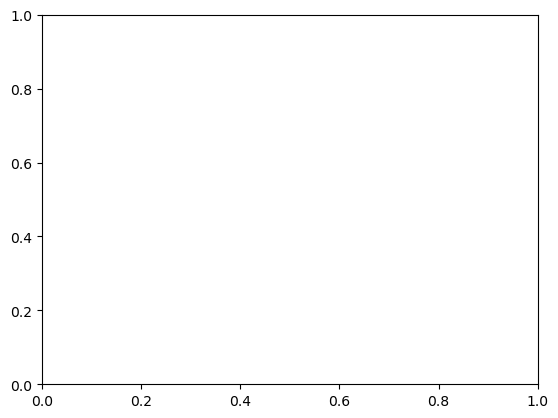

In [20]:
for i in lista_grupos:
    print(f'Inicio grupo: {i}')
    # selecciona el grupo de trabajo
    grupo_trabajo = get_grupo_trabajo(DF_GRUPOS_TRABAJO, i)
    # lista de codigos cañeros de grupo
    lista_codigos_caneros = list(grupo_trabajo['CODIGO CAÑERO'])
    # get codigo y nombre de delegado
    codigo_delegado, nombre_delegado = get_delegado_from_grupo(grupo_trabajo)
    nombre_delegado = nombre_delegado.replace('"', '')
    # convertir grupo a objeto
    obj_grupo = convertir_grupo_a_obj(grupo_trabajo)
    # get fecha actual
    fecha_cite = datetime.now().strftime("%Y-%m-%d")
    # registrar y obtener cite para informe
    cite = inserct_registro_y_get_id(fecha_cite, int(codigo_delegado), nombre_delegado, 'INSPECCION')
    # get fecha en formato dd/mm/aaaa
    fecha = datetime.now().strftime("%d/%m/%Y")
    # crear diccionario con datos para informe + grupo de trabajo
    datos_grupo = { 'fecha' : fecha, 'cite': cite, 'delegado':nombre_delegado, 'ca' : obj_grupo }
    # crea objeto de datos de grupo de trabajo
    datos_grupo = collections.namedtuple("insp", datos_grupo.keys())(*datos_grupo.values())
    # get qr con info del informe
    path_qr = get_qr(datos_grupo, codigo_delegado, nombre_delegado)
    # seleccionar catastro de grupo
    catastro_de_grupo = gdf_catrastro[gdf_catrastro['unidad_03'].isin(lista_codigos_caneros)].copy()
    # Convierte la columna 'unidad_01' a entero
    catastro_de_grupo['unidad_01'] = catastro_de_grupo['unidad_01'].astype(int)
    # lista de codigos de pripiedad
    lista_codigos_propiedad = list(set(catastro_de_grupo['unidad_01']))
    # pivotar catastro de grupo para totalizar areas
    df_data_props = pivotar_catastro_de_grupo(catastro_de_grupo)
    # convertir resumen de props a obj
    obj_props = convertir_resumen_props_a_obj(df_data_props)
    #
    # totales de columnas de resumen de props
    total_area = df_data_props['area_total'].sum()
    area_con_ctrl = df_data_props['area_con_ctrl'].sum()
    porcentaje_ctrl = (area_con_ctrl / total_area) * 100
    # convercion a obj de totales
    data_totales = { 'total_area' : total_area, 'area_con_ctrl': area_con_ctrl, 'porcentaje_ctrl' : porcentaje_ctrl }
    obj_totales = collections.namedtuple("totales", data_totales.keys())(*data_totales.values())
    
    path_tif = RUTA_UNIDAD_ONE_DRIVE + r"\Ingenio Azucarero Guabira S.A\UTEA - SEMANAL - CATASTRO\RASTER\SENTINEL_2026-04-04_UTM.tif"
    #path_tif = r"C:\Users\Usuario\Downloads\SENTINEL_2024-01-30_UTM.tif"
    lista_path_planos = []
    for cod_prop in lista_codigos_propiedad:
        # get nombre de propiedes desde obj obj_props
        print('Propiedad: ', str(cod_prop))
        area_aplicar = [p.area_con_ctrl for p in obj_props if p.unidad_01 == cod_prop][0]
        propiedad_grupo = catastro_de_grupo[catastro_de_grupo['unidad_01'] == cod_prop]
        propiedad_select = catastro_de_grupo[(catastro_de_grupo['unidad_01'] == cod_prop) & (catastro_de_grupo['ctrl_bio'] == True)]
        path_plano = generar_plano(propiedad_grupo, propiedad_select, path_tif, area_aplicar)
        lista_path_planos.append(path_plano)
        
    doc = DocxTemplate(PATH_COMPLETO+"/templates/tpl_rpt_ctrl_bio_notificacion_recomendacion.docx")
    in_line_qr = docxtpl.InlineImage(doc, image_descriptor=path_qr, width=Mm(30))
    lista_propiedades_Inline = []
    for plano in lista_path_planos:
        lista_propiedades_Inline.append(docxtpl.InlineImage(doc, image_descriptor=plano, width=Mm(150)))
    context = {'insp' : datos_grupo, 'propiedades' : obj_props, 'totales' : obj_totales, 'qr':in_line_qr, 'planos' : lista_propiedades_Inline,}
    doc.render(context)
    file_name = str(codigo_delegado) + '_INSP_' + datos_grupo.fecha.replace('/', '-') + '_' + nombre_delegado
    doc.save(PATH_COMPLETO + '/informes/_' + file_name + '.docx')
    print(f'Fin grupo: {i}')

In [1]:
codigo_trabajo = 60

In [2]:
grupo_trabajo = get_grupo_trabajo(DF_GRUPOS_TRABAJO, codigo_trabajo)
grupo_trabajo

NameError: name 'get_grupo_trabajo' is not defined

In [172]:
lista_codigos_caneros = list(grupo_trabajo['CODIGO CAÑERO'])
print(f'✅ Lista de codigos: {lista_codigos_caneros}')

✅ Lista de codigos: [9278]


In [173]:
codigo_delegado, nombre_delegado = get_delegado_from_grupo(grupo_trabajo)
print('✅ Deleagdo:', str(codigo_delegado) + " / " + nombre_delegado)

✅ Deleagdo: 9278 / NUÑEZ MARTINEZ BRAULIO


In [174]:
obj_grupo = convertir_grupo_a_obj(grupo_trabajo)
print(f'✅ Objeto de cañeros de grupo:')
obj_grupo

✅ Objeto de cañeros de grupo:


[canhero(inst=1, cod_ca=9278, nom_ca='NUÑEZ MARTINEZ BRAULIO')]

In [175]:
# get fecha actual
fecha_cite = datetime.now().strftime("%Y-%m-%d")
# registrar y obtener cite para informe
cite = inserct_registro_y_get_id(fecha_cite, int(codigo_delegado), nombre_delegado, 'INSPECCION')
print(f'✅ CITE creado: {cite}')

✅ CITE creado: 70


In [176]:
# get fecha en formato dd/mm/aaaa
fecha = datetime.now().strftime("%d/%m/%Y")
# crear diccionario con datos de grupo de trabajo
datos_grupo = { 'fecha' : fecha, 'cite': cite, 'delegado':nombre_delegado, 'ca' : obj_grupo }
# crea objeto de datos de grupo de trabajo
datos_grupo = collections.namedtuple("insp", datos_grupo.keys())(*datos_grupo.values())
print(f'✅ Objeto grupo de trabajo:')
datos_grupo

✅ Objeto grupo de trabajo:


insp(fecha='04/04/2026', cite=70, delegado='NUÑEZ MARTINEZ BRAULIO', ca=[canhero(inst=1, cod_ca=9278, nom_ca='NUÑEZ MARTINEZ BRAULIO')])

In [177]:
# get qr con info del informe
path_qr = get_qr(datos_grupo, codigo_delegado, nombre_delegado)
print(f'✅ Ruta de QR de informe:')
path_qr

✅ Ruta de QR de informe:


'C:\\Documents\\OneDrive - Ingenio Azucarero Guabira S.A\\_DATOS_PYTHON/planos/qr_9278_04-04-2026.png'

In [178]:
# seleccionar catastro de grupo
catastro_de_grupo = gdf_catrastro[gdf_catrastro['unidad_03'].isin(lista_codigos_caneros)].copy()
# Convierte la columna 'unidad_01' a entero
catastro_de_grupo['unidad_01'] = catastro_de_grupo['unidad_01'].astype(int)

In [179]:
lista_codigos_propiedad = list(set(catastro_de_grupo['unidad_01']))
lista_codigos_propiedad

[301, 302, 303, 304, 305]

In [180]:
df_data_props = pivotar_castro_de_grupo(catastro_de_grupo)
df_data_props

,unidad_01,unidad_02,area_total,area_con_ctrl,porcentaje_ctrl
0,301,SAN JORGE--NUNEZ BRAULIO,101.18,12.62,12.47
1,302,TOTAITU I--NUNEZ BRAULIO,42.36,27.40,64.68
2,303,TOTAITU II--NUNEZ BRAULIO,102.62,102.62,100.00
3,304,MONTES CLAROS--NUNEZ BRAULIO,51.32,2.57,5.01
4,305,LAS TRANCAS EL ARBOLITO--NUNEZ BRAULIO,134.45,77.50,57.64


In [181]:
obj_props = convertir_resumen_props_a_obj(df_data_props)
obj_props

[props(unidad_01=301, unidad_02='SAN JORGE--NUNEZ BRAULIO', total_area=101.18, area_con_ctrl=12.62, porcentaje_ctrl=12.47),
 props(unidad_01=302, unidad_02='TOTAITU I--NUNEZ BRAULIO', total_area=42.36, area_con_ctrl=27.400000000000002, porcentaje_ctrl=64.68),
 props(unidad_01=303, unidad_02='TOTAITU II--NUNEZ BRAULIO', total_area=102.62, area_con_ctrl=102.62, porcentaje_ctrl=100.0),
 props(unidad_01=304, unidad_02='MONTES CLAROS--NUNEZ BRAULIO', total_area=51.32, area_con_ctrl=2.57, porcentaje_ctrl=5.01),
 props(unidad_01=305, unidad_02='LAS TRANCAS EL ARBOLITO--NUNEZ BRAULIO', total_area=134.45, area_con_ctrl=77.5, porcentaje_ctrl=57.64)]

In [182]:
total_area = df_data_props['area_total'].sum()
area_con_ctrl = df_data_props['area_con_ctrl'].sum()
porcentaje_ctrl = (area_con_ctrl / total_area) * 100

In [183]:
data_totales = { 'total_area' : total_area, 'area_con_ctrl': area_con_ctrl, 'porcentaje_ctrl' : porcentaje_ctrl }
obj_totales = collections.namedtuple("totales", data_totales.keys())(*data_totales.values())
obj_totales

totales(total_area=431.93, area_con_ctrl=222.71, porcentaje_ctrl=51.56159562892135)

MemoryError: Unable to allocate 478. MiB for an array with shape (12508, 13366, 3) and data type uint8

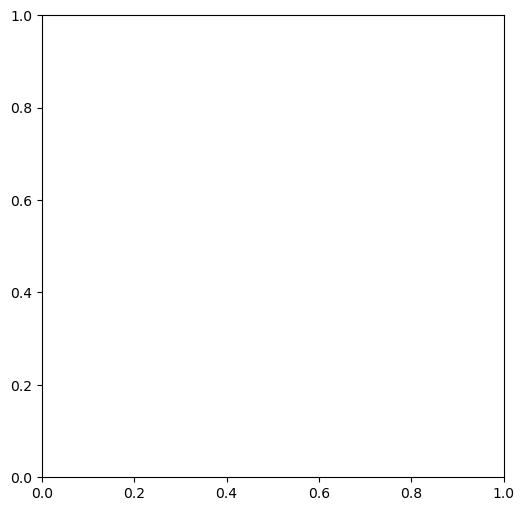

In [184]:
path_tif = RUTA_UNIDAD_ONE_DRIVE + r"\Ingenio Azucarero Guabira S.A\UTEA - SEMANAL - CATASTRO\RASTER\SENTINEL_2025-07-26_UTM.tif"
#path_tif = r"C:\Users\Usuario\Downloads\SENTINEL_2024-01-30_UTM.tif"
lista_path_planos = []
for cod_prop in lista_codigos_propiedad:
    # get nombre de propiedes desde obj obj_props
    area_aplicar = [p.area_con_ctrl for p in obj_props if p.unidad_01 == cod_prop][0]
    propiedad_grupo = catastro_de_grupo[catastro_de_grupo['unidad_01'] == cod_prop]
    propiedad_select = catastro_de_grupo[(catastro_de_grupo['unidad_01'] == cod_prop) & (catastro_de_grupo['ctrl_bio'] == True)]
    path_plano = generar_plano(propiedad_grupo, propiedad_select, path_tif, area_aplicar)
    lista_path_planos.append(path_plano)

In [101]:
doc = DocxTemplate(PATH_COMPLETO+"/templates/tpl_rpt_ctrl_bio_notificacion_recomendacion.docx")
in_line_qr = docxtpl.InlineImage(doc, image_descriptor=path_qr, width=Mm(30))
lista_propiedades_Inline = []
for plano in lista_path_planos:
    lista_propiedades_Inline.append(docxtpl.InlineImage(doc, image_descriptor=plano, width=Mm(150)))
context = {'insp' : datos_grupo, 'propiedades' : obj_props, 'totales' : obj_totales, 'qr':in_line_qr, 'planos' : lista_propiedades_Inline,}
doc.render(context)
file_name = str(codigo_delegado) + '_INSP_' + datos_grupo.fecha.replace('/', '-') + '_' + nombre_delegado
doc.save(PATH_COMPLETO + '/informes/_' + file_name + '.docx')